# House Price Prediction - EDA and Preprocessing

This notebook explores the House Prices dataset, checks data quality, and prepares a student-friendly understanding of preprocessing decisions.


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

BASE_DIR = Path.cwd().resolve().parents[0] if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_DIR = BASE_DIR / 'data'
train_path = DATA_DIR / 'train.csv'

df = pd.read_csv(train_path)
df.head()


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## 1. Basic information
We first inspect the shape, columns, and data types to understand the dataset.


In [2]:
print('Shape:', df.shape)
print('Data types:')
print(df.dtypes.head(20))

df.info()


Shape: (1460, 81)
Data types:
Id                int64
MSSubClass        int64
MSZoning            str
LotFrontage     float64
LotArea           int64
Street              str
Alley               str
LotShape            str
LandContour         str
Utilities           str
LotConfig           str
LandSlope           str
Neighborhood        str
Condition1          str
Condition2          str
BldgType            str
HouseStyle          str
OverallQual       int64
OverallCond       int64
YearBuilt         int64
dtype: object
<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-n

## 2. Summary statistics
We review descriptive statistics for numerical features.


In [3]:
df.describe().T.head(20)


,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0


## 3. Missing values
Missing values are very common in this dataset, especially for optional house features like alley, fireplace quality, fence, and pool quality.


In [4]:
missing = df.isnull().sum().sort_values(ascending=False)
missing = missing[missing > 0]
missing.head(20)


PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageQual        81
GarageFinish      81
GarageType        81
GarageYrBlt       81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtCond          37
BsmtQual          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64

## 4. Target variable distribution
The target variable is `SalePrice`. Understanding its distribution helps us see skewness and possible need for transformation.


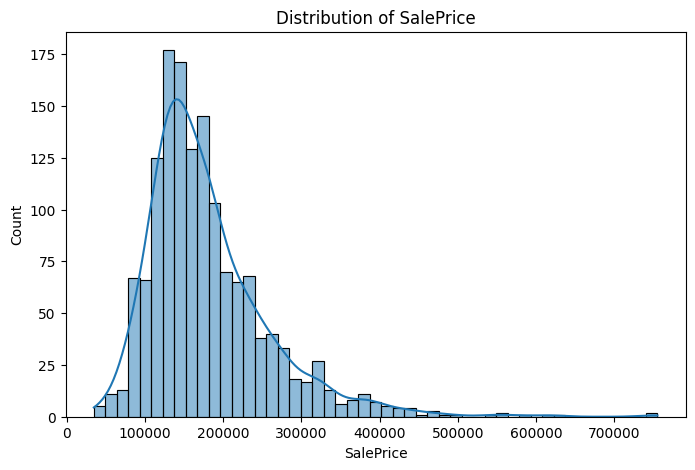

In [5]:
plt.figure(figsize=(8, 5))
sns.histplot(df['SalePrice'], kde=True)
plt.title('Distribution of SalePrice')
plt.show()


## 5. Correlation with numeric features
This helps identify strong linear relationships with the target.


In [6]:
corr = df.select_dtypes(include=['number']).corr(numeric_only=True)['SalePrice'].sort_values(ascending=False)
corr.head(15)


SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420
Name: SalePrice, dtype: float64

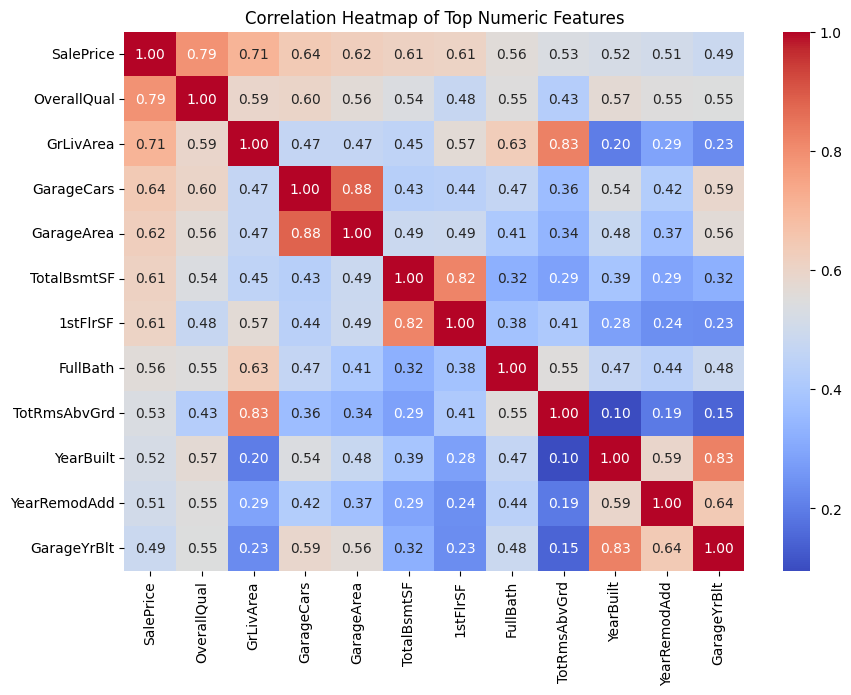

In [7]:
top_corr_features = corr.abs().sort_values(ascending=False).head(12).index
plt.figure(figsize=(10, 7))
sns.heatmap(df[top_corr_features].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap of Top Numeric Features')
plt.show()


## 6. Important categorical features
Neighborhood, house quality, and zoning often influence price strongly.


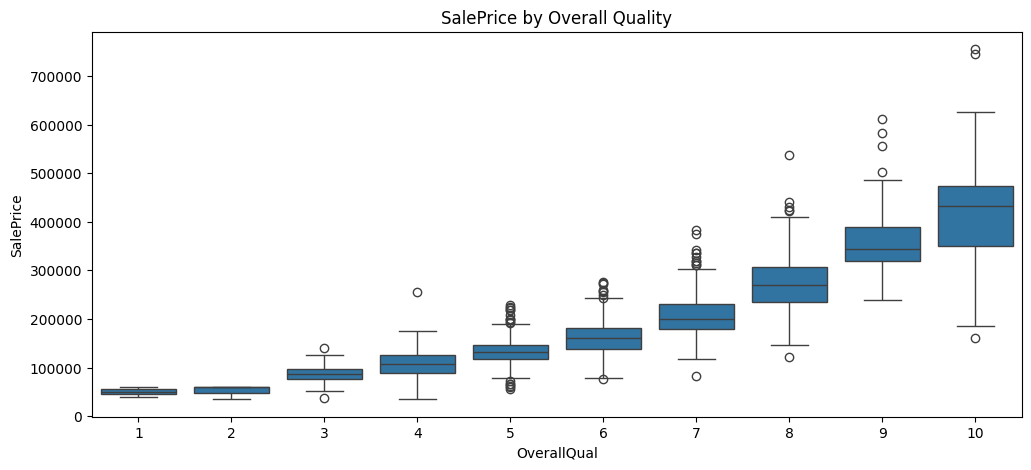

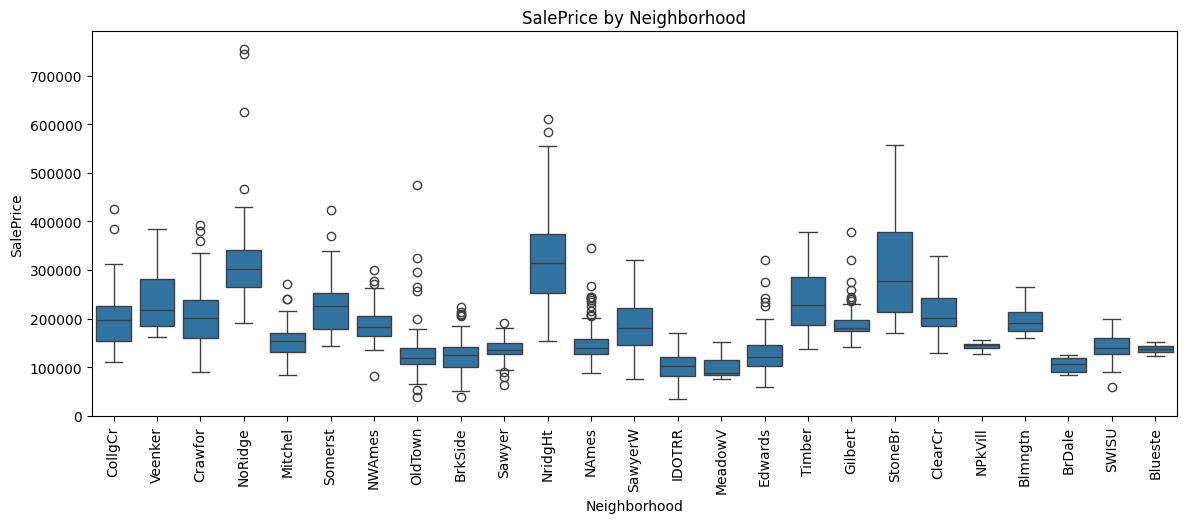

In [8]:
plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x='OverallQual', y='SalePrice')
plt.title('SalePrice by Overall Quality')
plt.show()

plt.figure(figsize=(14, 5))
sns.boxplot(data=df, x='Neighborhood', y='SalePrice')
plt.xticks(rotation=90)
plt.title('SalePrice by Neighborhood')
plt.show()


## 7. Preprocessing strategy
Planned preprocessing used in the Python scripts:

- Numerical columns: median imputation
- Categorical columns: most frequent imputation + one-hot encoding
- Scaling: applied for Linear Regression and Ridge Regression
- Train/test split: 80/20
- Evaluation: RMSE, MAE, and R²


In [9]:
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
categorical_cols = df.select_dtypes(exclude=['number']).columns.tolist()

print('Number of numerical columns:', len(numeric_cols))
print('Number of categorical columns:', len(categorical_cols))


Number of numerical columns: 38
Number of categorical columns: 43


## 8. EDA conclusion
Main observations:

- `SalePrice` is right-skewed.
- `OverallQual`, `GrLivArea`, `GarageCars`, and `TotalBsmtSF` are strongly related to price.
- The dataset contains many missing values, so preprocessing is essential.
- Both linear and non-linear regression models are worth testing.
